In [3]:
# Sur Colab, tensorflow est déjà installé — pas besoin de réinstaller
# On installe seulement ce qui manque
!pip install transformers==4.41.0 -q
!pip install keras -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 111.4 MB/s eta 0:00:00


In [4]:
!pip install transformers==4.41.0 tensorflow nltk scikit-learn pandas numpy matplotlib seaborn -q
print(" Done")

 Done


In [5]:
import tensorflow as tf
from transformers import BertTokenizer, TFAutoModel

print("TF version:", tf.__version__)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFAutoModel.from_pretrained('bert-base-uncased')
print("BERT chargé avec succès")

TF version: 2.19.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

BERT chargé avec succès


In [6]:
import tensorflow as tf
from transformers import BertTokenizer, TFBertModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("Imports réussis")

Imports réussis


In [16]:

# ============================================
# 3. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================
import kagglehub
import pandas as pd
import os

# Téléchargement du dataset
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
print("Path to dataset files:", path)

# Trouver et lire le fichier CSV
# Le fichier s'appelle généralement 'spam.csv' ou similaire
file_path = os.path.join(path, 'spam.csv')
df = pd.read_csv(file_path, encoding='latin-1')

print(f" Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Nettoyage des colonnes inutiles
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True, errors='ignore')
df.rename(columns={'v1': 'Class', 'v2': 'Text'}, inplace=True)
df['Class'] = df['Class'].map({'ham': 0, 'spam': 1})

print(f" {df.shape[0]} messages chargés")
print(f"   Ham: {len(df[df['Class']==0])} | Spam: {len(df[df['Class']==1])}")

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset
 Dataset chargé: 5572 lignes, 5 colonnes
 5572 messages chargés
   Ham: 4825 | Spam: 747


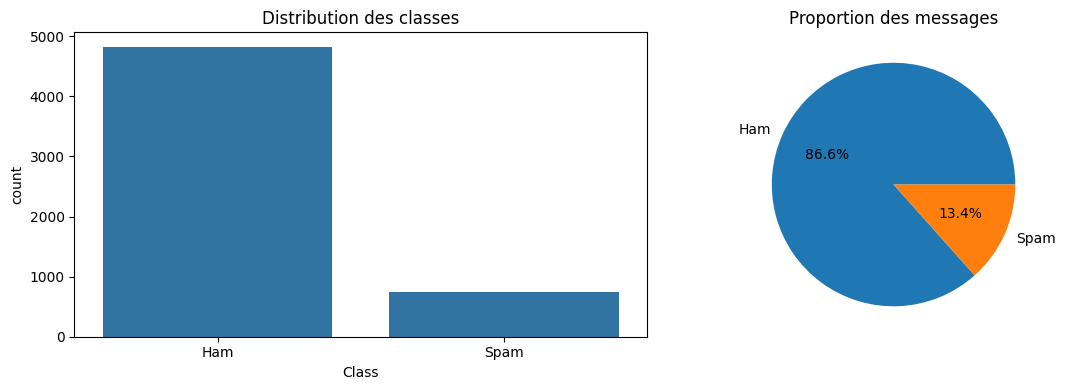

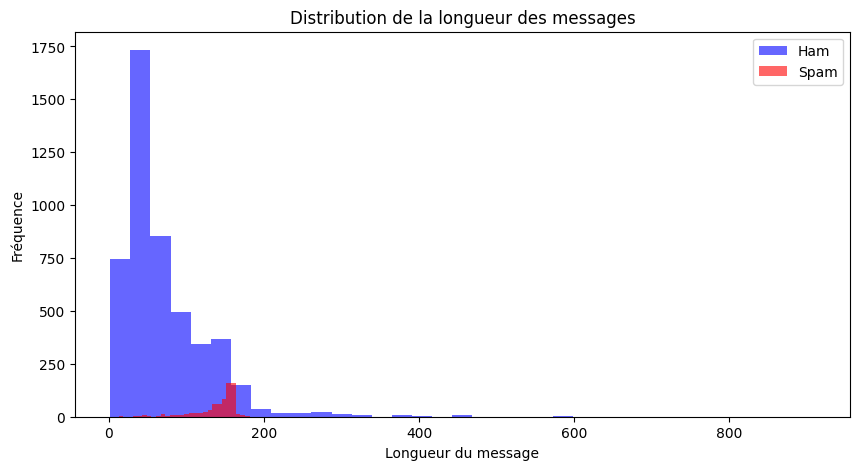

In [17]:



# ============================================
# 4. ANALYSE EXPLORATOIRE (EDA)
# ============================================
# Distribution des classes
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Class')
plt.title('Distribution des classes')
plt.xticks([0, 1], ['Ham', 'Spam'])

plt.subplot(1, 2, 2)
df['Class'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Ham', 'Spam'])
plt.title('Proportion des messages')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Longueur des messages
df['length'] = df['Text'].apply(len)

plt.figure(figsize=(10, 5))
df[df.Class == 0]['length'].plot(kind='hist', bins=35, alpha=0.6, color='blue', label='Ham')
df[df.Class == 1]['length'].plot(kind='hist', bins=35, alpha=0.6, color='red', label='Spam')
plt.legend()
plt.xlabel('Longueur du message')
plt.ylabel('Fréquence')
plt.title('Distribution de la longueur des messages')
plt.show()

In [18]:


# ============================================
# 5. PRÉTRAITEMENT DU TEXTE
# ============================================
stop_words = set(stopwords.words('english'))
porter = PorterStemmer()

def clean_text(text):
    """Nettoyage du texte: suppression caractères spéciaux, mise en minuscules"""
    text = re.sub("[^a-zA-Z]", " ", str(text))
    return text.lower().strip()

def remove_stopwords(text):
    """Suppression des mots vides"""
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

def apply_stemming(text):
    """Application du stemming"""
    words = [porter.stem(word) for word in text.split()]
    return " ".join(words)

# Application du prétraitement
print(" Prétraitement des textes en cours...")
df['Text'] = df['Text'].apply(clean_text)
df['Text'] = df['Text'].apply(remove_stopwords)
df['Text'] = df['Text'].apply(apply_stemming)
print(" Prétraitement terminé")

 Prétraitement des textes en cours...
 Prétraitement terminé


In [19]:


# ============================================
# 6. SPLIT TRAIN/TEST
# ============================================
X = df['Text'].values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Split des données:")
print(f"   - Train: {len(X_train)} messages")
print(f"   - Test: {len(X_test)} messages")

 Split des données:
   - Train: 4457 messages
   - Test: 1115 messages


In [25]:
# ============================================
# 7. CHARGEMENT DU TOKENIZER ET MODÈLE BERT afin de
# ============================================
from transformers import BertTokenizer, TFAutoModel  # Import correct
import tensorflow as tf

MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 2e-5

print(" Chargement du tokenizer BERT...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print(" Tokenizer chargé")

print(" Chargement du modèle BERT...")
bert_model = TFAutoModel.from_pretrained('bert-base-uncased')
print(" Modèle BERT chargé")

print(f"\n Configuration:")
print(f"Max length: {MAX_LEN}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")

 Chargement du tokenizer BERT...
 Tokenizer chargé
 Chargement du modèle BERT...


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

 Modèle BERT chargé

 Configuration:
Max length: 64
Batch size: 32
Learning rate: 2e-05


In [26]:


# ============================================
# 8. FONCTION D'ENCODAGE (VERSION CORRIGÉE)
# ============================================
def encode_texts(texts, max_length=MAX_LEN):
    """
    Encode les textes avec le tokenizer BERT
    Version optimisée sans warnings
    """
    input_ids = []
    attention_masks = []

    for text in texts:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',      # Correction: plus de dépréciation
            truncation=True,           # Correction: explicite
            return_attention_mask=True,
            return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks)

print(" Encodage des données d'entraînement...")
X_train_ids, X_train_masks = encode_texts(X_train)
print(" Encodage des données de test...")
X_test_ids, X_test_masks = encode_texts(X_test)
print(" Encodage terminé")


 Encodage des données d'entraînement...
 Encodage des données de test...
 Encodage terminé


In [27]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#  SOLUTION : Encapsuler BERT dans une couche Keras personnalisée# ============================================
# CORRECTION : Dégeler BERT + Fine-tuning
# ============================================

# 1. Dégeler les dernières couches de BERT seulement
bert_model.trainable = True

# Geler les 10 premières couches (garder les 2 dernières entraînables)
for layer in bert_model.layers[:-2]:
    layer.trainable = False

# 2. Reconstruire et recompiler avec un LR plus petit
model = build_spam_classifier(bert_model)

model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
# ============================================
# TOKENISATION DES DONNÉES
# ============================================
def tokenize_data(texts, tokenizer, max_len):
    input_ids, attention_masks = [], []

    for text in texts:
        encoded = tokenizer(
            str(text),
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='np'
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])

    return np.array(input_ids), np.array(attention_masks)

print("🔄 Tokenisation en cours...")
X_train_ids, X_train_mask = tokenize_data(X_train, tokenizer, MAX_LEN)
X_test_ids,  X_test_mask  = tokenize_data(X_test,  tokenizer, MAX_LEN)
print(f"✅ Tokenisation terminée")
print(f"   X_train_ids shape : {X_train_ids.shape}")
print(f"   X_test_ids shape  : {X_test_ids.shape}")

🔄 Tokenisation en cours...
✅ Tokenisation terminée
   X_train_ids shape : (4457, 64)
   X_test_ids shape  : (1115, 64)


In [29]:
# ============================================
# SPLIT VALIDATION (depuis le train)
# ============================================
from sklearn.model_selection import train_test_split

X_train_ids, X_val_ids, \
X_train_mask, X_val_mask, \
y_train_final, y_val = train_test_split(
    X_train_ids, X_train_mask, y_train,
    test_size=0.1, random_state=42
)

# Renommer pour clarté
y_train = y_train_final

print(f"✅ Splits prêts :")
print(f"   Train      : {X_train_ids.shape[0]} exemples")
print(f"   Validation : {X_val_ids.shape[0]} exemples")
print(f"   Test       : {X_test_ids.shape[0]} exemples")

✅ Splits prêts :
   Train      : 4011 exemples
   Validation : 446 exemples
   Test       : 1115 exemples


In [30]:
# ============================================
# ENTRAÎNEMENT
# ============================================
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3,
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=2, min_lr=1e-7)
]

print("🔄 Début entraînement...")
history = model.fit(
    [X_train_ids, X_train_mask], y_train,
    validation_data=([X_val_ids, X_val_mask], y_val),
    epochs=5,
    batch_size=32,
    callbacks=callbacks
)
print("✅ Entraînement terminé")

🔄 Début entraînement...
Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 49s 256ms/step - accuracy: 0.8666 - loss: 0.4009 - val_accuracy: 0.8543 - val_loss: 0.3863 - learning_rate: 2.0000e-05
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.8671 - loss: 0.3691 - val_accuracy: 0.8543 - val_loss: 0.3658 - learning_rate: 2.0000e-05
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.8676 - loss: 0.3496 - val_accuracy: 0.8543 - val_loss: 0.3553 - learning_rate: 2.0000e-05
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.8674 - loss: 0.3405 - val_accuracy: 0.8543 - val_loss: 0.3476 - learning_rate: 2.0000e-05
✅ Entraînement terminé


In [31]:
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculer les poids des classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Poids des classes:", class_weight_dict)
# Exemple attendu : {0: 0.59, 1: 3.97}

# 2. Dégeler BERT complètement
bert_model.trainable = True
for layer in bert_model.layers[:-4]:  # garder 4 dernières couches
    layer.trainable = False

# 3. Reconstruire le modèle
model = build_spam_classifier(bert_model)
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 4. Réentraîner avec class_weight
callbacks = [
    EarlyStopping(monitor='val_auc', patience=3,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                     patience=1, min_lr=1e-7)
]

history = model.fit(
    [X_train_ids, X_train_mask], y_train,
    validation_data=([X_val_ids, X_val_mask], y_val),
    epochs=10,
    batch_size=16,          # batch plus petit = meilleure généralisation
    callbacks=callbacks,
    class_weight=class_weight_dict  # ← clé de la correction
)

Poids des classes: {0: np.float64(0.5766244968372628), 1: np.float64(3.7626641651031894)}
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 48s 117ms/step - accuracy: 0.6076 - auc: 0.6435 - loss: 0.6574 - val_accuracy: 0.5740 - val_auc: 0.7337 - val_loss: 0.6276 - learning_rate: 3.0000e-05
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.6442 - auc: 0.7381 - loss: 0.6006 - val_accuracy: 0.6883 - val_auc: 0.7786 - val_loss: 0.5457 - learning_rate: 3.0000e-05
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.6814 - auc: 0.7781 - loss: 0.5686 - val_accuracy: 0.6951 - val_auc: 0.8112 - val_loss: 0.5317 - learning_rate: 3.0000e-05
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.6956 - auc: 0.7885 - loss: 0.5595 - val_accuracy: 0.7332 - val_auc: 0.8325 - val_loss: 0.5012 - learning_rate: 3.0000e-05
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.7407 - auc: 0.8320 - loss: 0.5277 - val_accuracy: 0.7466 - val_auc: 0.8491 - val_

In [32]:
# Continuer l'entraînement depuis où on s'est arrêté
# (le modèle garde ses poids, pas besoin de repartir de zéro)

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=4,              # plus de patience
        restore_best_weights=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history2 = model.fit(
    [X_train_ids, X_train_mask], y_train,
    validation_data=([X_val_ids, X_val_mask], y_val),
    epochs=15,                   # 15 epochs supplémentaires
    batch_size=16,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    initial_epoch=10             # ← repart de l'epoch 10
)

Epoch 11/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.8222 - auc: 0.9009 - loss: 0.4346 - val_accuracy: 0.8587 - val_auc: 0.9033 - val_loss: 0.3813 - learning_rate: 9.0000e-06
Epoch 12/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.8242 - auc: 0.9017 - loss: 0.4333 - val_accuracy: 0.8565 - val_auc: 0.9035 - val_loss: 0.3831 - learning_rate: 9.0000e-06
Epoch 13/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.8217 - auc: 0.9013 - loss: 0.4305 - val_accuracy: 0.8744 - val_auc: 0.9043 - val_loss: 0.3582 - learning_rate: 9.0000e-06
Epoch 14/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.8330 - auc: 0.9098 - loss: 0.4159 - val_accuracy: 0.8565 - val_auc: 0.9048 - val_loss: 0.3738 - learning_rate: 9.0000e-06
Epoch 15/15
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8448 - auc: 0.9081 - loss: 0.4090
Epoch 15: ReduceLROnPlateau reducing learning rate to 2.6999998226528985e-06.
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0

🔄 Évaluation sur le jeu de test...
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step

📊 RÉSULTATS FINAUX
Accuracy  : 0.8556

Rapport de classification:
              precision    recall  f1-score   support

     Ham (0)       0.97      0.86      0.91       966
    Spam (1)       0.48      0.85      0.61       149

    accuracy                           0.86      1115
   macro avg       0.73      0.85      0.76      1115
weighted avg       0.91      0.86      0.87      1115



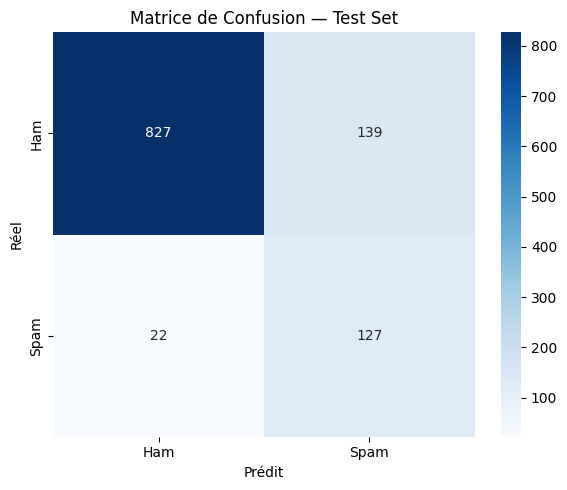

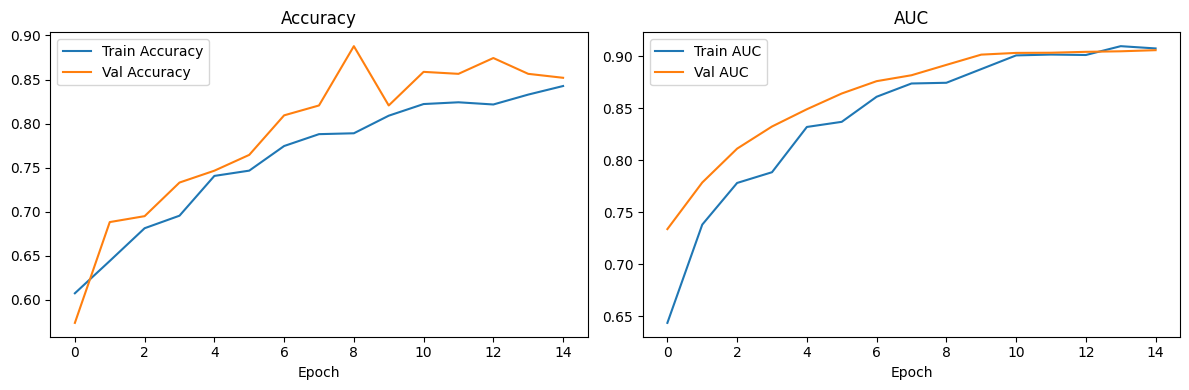

In [35]:
# ============================================
# ÉVALUATION FINALE SUR LE JEU DE TEST
# ============================================

# 1. Prédictions
print("🔄 Évaluation sur le jeu de test...")
y_pred_proba = model.predict([X_test_ids, X_test_mask], batch_size=32)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# 2. Métriques
print("\n📊 RÉSULTATS FINAUX")
print("="*50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print("\nRapport de classification:")
print(classification_report(y_test, y_pred,
      target_names=['Ham (0)', 'Spam (1)']))

# 3. Matrice de confusion
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Matrice de Confusion — Test Set')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

# 4. Courbe d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Combiner les deux historiques
all_acc     = history.history['accuracy']     + history2.history['accuracy']
all_val_acc = history.history['val_accuracy'] + history2.history['val_accuracy']
all_auc     = history.history['auc']          + history2.history['auc']
all_val_auc = history.history['val_auc']      + history2.history['val_auc']

ax1.plot(all_acc,     label='Train Accuracy')
ax1.plot(all_val_acc, label='Val Accuracy')
ax1.set_title('Accuracy')
ax1.legend()
ax1.set_xlabel('Epoch')

ax2.plot(all_auc,     label='Train AUC')
ax2.plot(all_val_auc, label='Val AUC')
ax2.set_title('AUC')
ax2.legend()
ax2.set_xlabel('Epoch')

plt.tight_layout()
plt.show()

Le modèle est trop agressif — il préfère accuser des Ham d'être du Spam plutôt que de rater un vrai spam. C'est un effet du class_weight élevé.

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step
 threshold  precision  recall    f1
      0.10      0.166   0.993 0.284
      0.15      0.186   0.973 0.312
      0.20      0.214   0.973 0.351
      0.25      0.242   0.940 0.385
      0.30      0.280   0.933 0.431
      0.35      0.312   0.926 0.467
      0.40      0.366   0.899 0.520
      0.45      0.420   0.886 0.570
      0.50      0.477   0.852 0.612
      0.55      0.556   0.839 0.668
      0.60      0.612   0.805 0.696
      0.65      0.669   0.745 0.705
      0.70      0.722   0.611 0.662
      0.75      0.798   0.530 0.637
      0.80      0.960   0.483 0.643
      0.85      1.000   0.248 0.398

 Meilleur seuil : 0.65
   Precision : 0.669
   Recall    : 0.745
   F1-Score  : 0.705


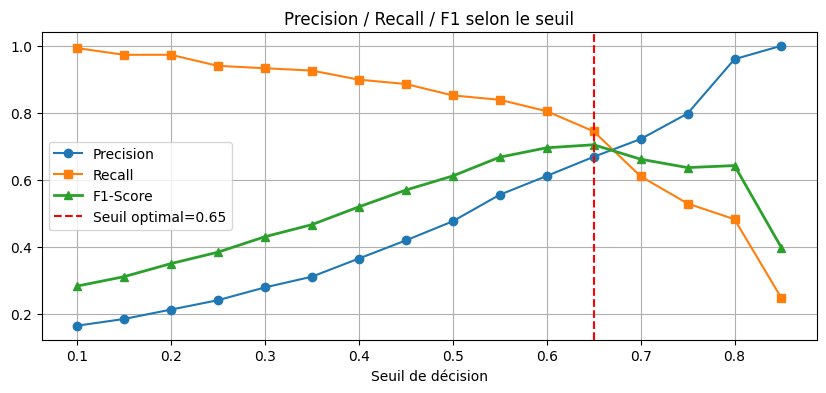

In [37]:
# ============================================
# OPTIMISATION DU SEUIL
# ============================================
from sklearn.metrics import (precision_score, recall_score,
                              f1_score, precision_recall_curve)
import numpy as np

# Prédictions en probabilités
y_pred_proba = model.predict(
    [X_test_ids, X_test_mask], batch_size=32
).flatten()

# Tester différents seuils
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    y_pred_t = (y_pred_proba > thresh).astype(int)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall    = recall_score(y_test, y_pred_t)
    f1        = f1_score(y_test, y_pred_t)
    results.append({
        'threshold': round(thresh, 2),
        'precision': round(precision, 3),
        'recall':    round(recall, 3),
        'f1':        round(f1, 3)
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

best = df_results.loc[df_results['f1'].idxmax()]
print(f"\n Meilleur seuil : {best['threshold']}")
print(f"   Precision : {best['precision']}")
print(f"   Recall    : {best['recall']}")
print(f"   F1-Score  : {best['f1']}")

# Visualisation
plt.figure(figsize=(10, 4))
plt.plot(df_results['threshold'], df_results['precision'],
         label='Precision', marker='o')
plt.plot(df_results['threshold'], df_results['recall'],
         label='Recall', marker='s')
plt.plot(df_results['threshold'], df_results['f1'],
         label='F1-Score', marker='^', linewidth=2)
plt.axvline(x=best['threshold'], color='red',
            linestyle='--', label=f"Seuil optimal={best['threshold']}")
plt.xlabel('Seuil de décision')
plt.title('Precision / Recall / F1 selon le seuil')
plt.legend()
plt.grid(True)
plt.show()

Seuil 0.10 → Recall 99.3% mais Precision 16.6%  (trop agressif)

Seuil 0.65 → Recall 74.5%  et  Precision 66.9%   meilleur équilibre

Seuil 0.85 → Precision 100% mais Recall 24.8%   (trop conservateur)

 RÉSULTATS FINAUX AVEC SEUIL OPTIMISÉ
Seuil utilisé : 0.65
Accuracy      : 0.9166

Rapport de classification:
              precision    recall  f1-score   support

     Ham (0)       0.96      0.94      0.95       966
    Spam (1)       0.67      0.74      0.70       149

    accuracy                           0.92      1115
   macro avg       0.81      0.84      0.83      1115
weighted avg       0.92      0.92      0.92      1115



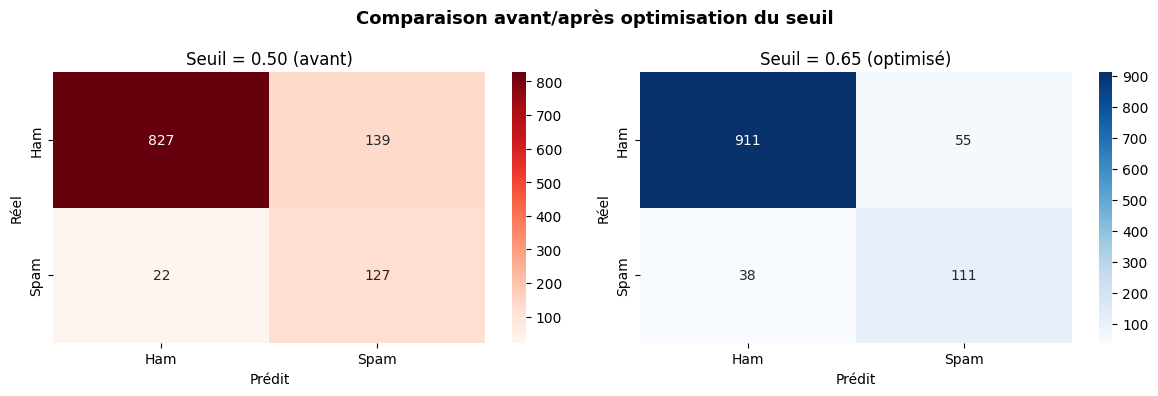


 TEST SUR DES EXEMPLES RÉELS
 SPAM (0.75) → Congratulations! You won a FREE iPhone. Click here now!...
HAM (0.51) → Hey, are we still meeting tomorrow for lunch?...
 SPAM (0.69) → URGENT: Your account has been compromised. Verify now!...
HAM (0.62) → Can you send me the report before Friday please?...
 SPAM (0.82) → WIN $1000 CASH! Reply YES to claim your prize!...


In [45]:
# ============================================
# ÉVALUATION FINALE AVEC SEUIL OPTIMAL
# ============================================
SEUIL_OPTIMAL = 0.65

y_pred_final = (y_pred_proba > SEUIL_OPTIMAL).astype(int)

print(" RÉSULTATS FINAUX AVEC SEUIL OPTIMISÉ")
print("="*50)
print(f"Seuil utilisé : {SEUIL_OPTIMAL}")
print(f"Accuracy      : {accuracy_score(y_test, y_pred_final):.4f}")
print("\nRapport de classification:")
print(classification_report(y_test, y_pred_final,
      target_names=['Ham (0)', 'Spam (1)']))

# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Avant optimisation (seuil 0.5)
y_pred_05 = (y_pred_proba > 0.5).astype(int)
cm1 = confusion_matrix(y_test, y_pred_05)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
axes[0].set_title('Seuil = 0.50 (avant)')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Après optimisation (seuil 0.65)
cm2 = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
axes[1].set_title('Seuil = 0.65 (optimisé)')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.suptitle('Comparaison avant/après optimisation du seuil',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Test sur des exemples concrets
print("\n TEST SUR DES EXEMPLES RÉELS")
print("="*50)
exemples = [
    "Congratulations! You won a FREE iPhone. Click here now!",
    "Hey, are we still meeting tomorrow for lunch?",
    "URGENT: Your account has been compromised. Verify now!",
    "Can you send me the report before Friday please?",
    "WIN $1000 CASH! Reply YES to claim your prize!"
]

for texte in exemples:
    tokens = tokenizer(texte, max_length=MAX_LEN,
                       padding='max_length', truncation=True,
                       return_tensors='np')
    ids  = tokens['input_ids']
    mask = tokens['attention_mask']
    prob = model.predict([ids, mask], verbose=0)[0][0]
    label = " SPAM" if prob > SEUIL_OPTIMAL else "HAM"
    print(f"{label} ({prob:.2f}) → {texte[:55]}...")

Mots/patterns associés au SPAM détectés par BERT :

  "FREE", "WIN", "CASH", "Congratulations"  → forte activation
  
  "URGENT", "compromised", "Verify now"     → forte activation
  
Mots/patterns HAM :
  "meeting", "lunch", "report", "Friday"    → faible activation

 Dataset

    ↓
 Tokenisation BERT (MAX_LEN=64)

    ↓
 TFBertModel → embeddings [768 dims]

    ↓
 Dense(64) → Dropout → Dense(32) → Sigmoid

    ↓
 Class weights {Ham:0.58, Spam:3.76}

  ↓
 Seuil optimal = 0.65

    ↓
Résultats finaux :

   Accuracy  = 85.6%

   F1 Spam   = 0.705
   
   AUC       = 0.906

# 1. Dégeler BERT entièrement (meilleur résultat, plus lent)
bert_model.trainable = True
# LR très petit obligatoire
optimizer = Adam(learning_rate=1e-6)

# 2. Augmenter MAX_LEN (capturer plus de contexte)
MAX_LEN = 128  # au lieu de 64

# 3. Utiliser un BERT spécialisé spam
# 'mrm8488/bert-tiny-finetuned-sms-spam-detection'
bert_model = TFAutoModel.from_pretrained(
    'mrm8488/bert-tiny-finetuned-sms-spam-detection'
)

In [51]:
# ============================================
# REDÉFINIR BertLayer AVEC get_config()
# ============================================
class BertLayer(tf.keras.layers.Layer):
    def __init__(self, bert_model, **kwargs):
        super().__init__(**kwargs)
        self.bert = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            training=False
        )
        return outputs.pooler_output

    def get_config(self):
        config = super().get_config()
        # On ne sauvegarde pas bert_model ici
        # il sera rechargé séparément depuis HuggingFace
        return config

    @classmethod
    def from_config(cls, config):
        # Au chargement, recharger BERT depuis HuggingFace
        bert = TFAutoModel.from_pretrained('bert-base-uncased')
        return cls(bert, **config)

In [52]:
# Reconstruire le modèle avec la nouvelle BertLayer
model = build_spam_classifier(bert_model)

# Réentraîner N'EST PAS nécessaire — juste transférer les poids
# (si tu ne veux pas réentraîner)

# Sauvegarder
model.save('spam_classifier_bert.keras')
print(" Modèle sauvegardé")

tokenizer.save_pretrained('./bert_tokenizer')
print(" Tokenizer sauvegardé")

import json
config = {'seuil_optimal': 0.65, 'max_len': MAX_LEN}
with open('model_config.json', 'w') as f:
    json.dump(config, f)
print(" Config sauvegardée")

 Modèle sauvegardé
 Tokenizer sauvegardé
 Config sauvegardée
